# Неделя 3 — анализ ошибок и консервативная калибровка RUL-модели

## 1. Постановка задачи недели

На второй неделе были получены две сильные RandomForest-модели:
- модель на сыром окне длиной 100 циклов;
- модель на агрегатных признаках по окну длиной 50 циклов.

Сырая модель дала лучший исходный результат по MAE, но обучается дольше и хуже интерпретируется. Агрегатная модель немного уступает по исходной MAE, но обучается быстрее и использует более понятные признаки.

Цель третьей недели — не просто улучшить MAE, а понять, где модель ошибается и насколько эти ошибки опасны для задачи прогнозирования остаточного ресурса авиационного двигателя.

## 2. Загрузка данных и воспроизведение моделей

Воспроизводим две лучшие RandomForest-линии из второй недели. Новые модели здесь не добавляются: это финальный explanatory notebook для анализа ошибок и консервативной калибровки.

In [1]:
import itertools
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

DATA_DIR = Path("CMAPSSData")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

columns = [
    "unit_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21",
]

target_col = "Remaining Useful Life"

rf_params = {
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf": 3,
    "min_samples_split": 5,
    "random_state": 42,
    "n_jobs": -1,
}

raw_window_size = 100
raw_excluded_sensor_cols = ["sensor_11"]
aggregated_window_size = 50
edge_window_size = 10
selected_optional_pairs = [
    "edge_means",
    "energy_acceleration",
    "last_first",
    "median_iqr",
    "relative_changes",
]
shift_min = 0.0
shift_max = 30.0
shift_step = 0.1
shift_round_digits = 3
shifts = np.round(
    np.arange(shift_min, shift_max + shift_step / 2, shift_step), shift_round_digits
)

In [2]:
def load_cmapss_fd001(data_dir):
    train_df = pd.read_csv(
        data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    test_df = pd.read_csv(
        data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    rul_test_df = pd.read_csv(
        data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
    )
    return train_df, test_df, rul_test_df


def add_rul_target(train_df):
    train_df = train_df.copy()
    max_cycle_per_unit = train_df.groupby("unit_id")["cycle"].max()
    train_df[target_col] = (
        train_df["unit_id"].map(max_cycle_per_unit) - train_df["cycle"]
    )
    return train_df


train_df, test_df, rul_test_df = load_cmapss_fd001(DATA_DIR)
train_df = add_rul_target(train_df)
y_test_official = rul_test_df["RUL"].reset_index(drop=True)
feature_cols = [
    col
    for col in train_df.columns
    if col.startswith("op_setting_") or col.startswith("sensor_")
]

test_unit_ids = (
    test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)["unit_id"]
    .sort_values()
    .reset_index(drop=True)
)
if len(test_unit_ids) != len(y_test_official):
    raise ValueError("Количество test unit_id должно совпадать с RUL_FD001")

pd.DataFrame(
    {
        "dataset": ["train_FD001", "test_FD001", "RUL_FD001"],
        "rows": [len(train_df), len(test_df), len(rul_test_df)],
    }
)

,dataset,rows
0,train_FD001,20631
1,test_FD001,13096
2,RUL_FD001,100


In [3]:
def evaluate_regression(y_true, y_pred):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    error = y_pred - y_true
    abs_error = error.abs()
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
        "mean_error": float(error.mean()),
        "median_abs_error": float(abs_error.median()),
        "max_abs_error": float(abs_error.max()),
    }


def build_error_table(unit_ids, y_true, y_pred, model_name):
    error_df = pd.DataFrame(
        {
            "model_name": model_name,
            "unit_id": pd.Series(unit_ids).to_numpy(),
            "true_rul": pd.Series(y_true).to_numpy(),
            "pred_rul": pd.Series(y_pred).to_numpy(),
        }
    )
    error_df["error"] = error_df["pred_rul"] - error_df["true_rul"]
    error_df["abs_error"] = error_df["error"].abs()
    error_df["error_type"] = np.select(
        [error_df["error"] > 0, error_df["error"] < 0],
        ["overestimation", "underestimation"],
        default="exact",
    )
    return error_df


def assign_rul_zone(true_rul):
    if true_rul <= 30:
        return "near_failure"
    if true_rul <= 70:
        return "warning_zone"
    if true_rul <= 120:
        return "mid_life"
    return "long_rul"


def safety_summary(error_df):
    over_errors = error_df.loc[error_df["error"] > 0, "error"]
    near_failure_df = error_df[error_df["true_rul"] <= 30]
    near_mae = (
        mean_absolute_error(near_failure_df["true_rul"], near_failure_df["pred_rul"])
        if len(near_failure_df)
        else np.nan
    )
    near_over_share = (
        float((near_failure_df["error"] > 0).mean()) if len(near_failure_df) else np.nan
    )
    return {
        "model_name": error_df["model_name"].iloc[0],
        "MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error": float(error_df["error"].mean()),
        "median_abs_error": float(error_df["abs_error"].median()),
        "overestimation_count": int((error_df["error"] > 0).sum()),
        "overestimation_share": float((error_df["error"] > 0).mean()),
        "mean_overestimation": float(over_errors.mean()) if len(over_errors) else 0.0,
        "max_overestimation": float(over_errors.max()) if len(over_errors) else 0.0,
        "near_failure_MAE": near_mae,
        "near_failure_overestimation_share": near_over_share,
    }


def evaluate_by_rul_zones(error_df):
    zone_df = error_df.copy()
    zone_df["zone"] = zone_df["true_rul"].apply(assign_rul_zone)
    rows = []
    for zone in ["near_failure", "warning_zone", "mid_life", "long_rul"]:
        subset = zone_df[zone_df["zone"] == zone]
        over_errors = subset.loc[subset["error"] > 0, "error"]
        rows.append(
            {
                "model_name": error_df["model_name"].iloc[0],
                "zone": zone,
                "count": len(subset),
                "MAE": (
                    mean_absolute_error(subset["true_rul"], subset["pred_rul"])
                    if len(subset)
                    else np.nan
                ),
                "RMSE": (
                    mean_squared_error(subset["true_rul"], subset["pred_rul"]) ** 0.5
                    if len(subset)
                    else np.nan
                ),
                "overestimation_share": (
                    float((subset["error"] > 0).mean()) if len(subset) else np.nan
                ),
                "mean_overestimation": (
                    float(over_errors.mean()) if len(over_errors) else 0.0
                ),
                "max_overestimation": (
                    float(over_errors.max()) if len(over_errors) else 0.0
                ),
            }
        )
    return pd.DataFrame(rows)

In [4]:
def build_lag_window_features(
    source_df,
    selected_feature_cols,
    window_size,
    include_target=False,
    require_full_window=False,
):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    first_values = sorted_df.groupby("unit_id")[selected_feature_cols].transform(
        "first"
    )
    lagged_parts = []
    for lag in range(window_size - 1, -1, -1):
        shifted = sorted_df.groupby("unit_id")[selected_feature_cols].shift(lag)
        if not require_full_window:
            shifted = shifted.fillna(first_values)
        suffix = "t" if lag == 0 else f"t_minus_{lag}"
        shifted.columns = [f"{col}_{suffix}" for col in selected_feature_cols]
        lagged_parts.append(shifted)
    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)
    result_df = pd.concat([sorted_df[metadata_cols], *lagged_parts], axis=1)
    if require_full_window:
        result_df = result_df[result_df["cycle"] >= window_size].dropna()
    return result_df.reset_index(drop=True)


raw_feature_cols = [col for col in feature_cols if col not in raw_excluded_sensor_cols]
raw_window_train_df = build_lag_window_features(
    train_df,
    raw_feature_cols,
    raw_window_size,
    include_target=True,
    require_full_window=True,
)
raw_window_test_df = build_lag_window_features(
    test_df,
    raw_feature_cols,
    raw_window_size,
    include_target=False,
    require_full_window=False,
)
raw_window_feature_cols = [
    col
    for col in raw_window_train_df.columns
    if col not in ["unit_id", "cycle", target_col]
]
raw_window_test_last_rows = (
    raw_window_test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_raw = raw_window_train_df[raw_window_feature_cols]
y_train_raw = raw_window_train_df[target_col].reset_index(drop=True)
X_test_raw = raw_window_test_last_rows[raw_window_feature_cols]
y_test_raw = y_test_official
raw_test_unit_ids = raw_window_test_last_rows["unit_id"].reset_index(drop=True)

raw_model = RandomForestRegressor(**rf_params)
raw_train_start = time.perf_counter()
raw_model.fit(X_train_raw, y_train_raw)
raw_train_seconds = time.perf_counter() - raw_train_start
raw_pred = raw_model.predict(X_test_raw)
raw_error_df = build_error_table(
    raw_test_unit_ids, y_test_raw, raw_pred, "Raw lag-window RF"
)

In [5]:
extended_agg_feature_cols = feature_cols
eps = 1e-8
mandatory_feature_blocks = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "delta",
    "slope",
    "last_minus_mean",
]
optional_feature_pairs = {
    "median_iqr": ["median", "iqr"],
    "last_first": ["last", "first"],
    "relative_changes": ["relative_delta", "relative_last_minus_mean"],
    "edge_means": ["mean_last_10", "mean_first_10"],
    "energy_acceleration": ["rms", "slope_change"],
}
selected_optional_blocks = list(
    itertools.chain.from_iterable(
        optional_feature_pairs[pair_name] for pair_name in selected_optional_pairs
    )
)
selected_agg_blocks = mandatory_feature_blocks + selected_optional_blocks


def calculate_slope(values):
    x = np.arange(len(values))
    x = x - x.mean()
    denominator = (x**2).sum()
    if denominator == 0:
        return 0
    return np.dot(values, x) / denominator


def calculate_first_edge_mean(values):
    return values[:edge_window_size].mean()


def calculate_rms(values):
    return np.sqrt(np.mean(values**2))


def calculate_slope_change(values):
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def rename_feature_block(block, suffix):
    renamed_block = block.copy()
    renamed_block.columns = [
        f"{col}_{suffix}_{aggregated_window_size}" for col in renamed_block.columns
    ]
    return renamed_block

In [6]:
def build_all_agg_window_features(
    source_df, include_target=False, require_full_window=False
):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    min_periods = aggregated_window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1
    rolling_features = sorted_df.groupby("unit_id")[extended_agg_feature_cols].rolling(
        window=aggregated_window_size, min_periods=min_periods
    )
    edge_rolling_features = sorted_df.groupby("unit_id")[
        extended_agg_feature_cols
    ].rolling(window=edge_window_size, min_periods=edge_min_periods)
    mean_features = rolling_features.mean().reset_index(level=0, drop=True)
    std_features = (
        rolling_features.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    )
    min_features = rolling_features.min().reset_index(level=0, drop=True)
    max_features = rolling_features.max().reset_index(level=0, drop=True)
    median_features = rolling_features.median().reset_index(level=0, drop=True)
    q25_features = rolling_features.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling_features.quantile(0.75).reset_index(level=0, drop=True)
    range_features = max_features - min_features
    iqr_features = q75_features - q25_features
    first_features = sorted_df.groupby("unit_id")[extended_agg_feature_cols].shift(
        aggregated_window_size - 1
    )
    if not require_full_window:
        first_available_values = sorted_df.groupby("unit_id")[
            extended_agg_feature_cols
        ].transform("first")
        first_features = first_features.fillna(first_available_values)
    last_features = sorted_df[extended_agg_feature_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    relative_delta_features = delta_features / (first_features.abs() + eps)
    relative_last_minus_mean_features = last_minus_mean_features / (
        mean_features.abs() + eps
    )
    mean_last_10_features = edge_rolling_features.mean().reset_index(level=0, drop=True)
    mean_first_10_features = rolling_features.apply(
        calculate_first_edge_mean, raw=True
    ).reset_index(level=0, drop=True)
    slope_features = rolling_features.apply(calculate_slope, raw=True).reset_index(
        level=0, drop=True
    )
    rms_features = rolling_features.apply(calculate_rms, raw=True).reset_index(
        level=0, drop=True
    )
    slope_change_features = rolling_features.apply(
        calculate_slope_change, raw=True
    ).reset_index(level=0, drop=True)
    feature_blocks = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": range_features,
        "delta": delta_features,
        "slope": slope_features,
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": iqr_features,
        "first": first_features,
        "last": last_features,
        "relative_delta": relative_delta_features,
        "relative_last_minus_mean": relative_last_minus_mean_features,
        "mean_first_10": mean_first_10_features,
        "mean_last_10": mean_last_10_features,
        "rms": rms_features,
        "slope_change": slope_change_features,
    }
    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)
    renamed_feature_blocks = {
        suffix: rename_feature_block(block, suffix)
        for suffix, block in feature_blocks.items()
    }
    result_df = pd.concat(
        [sorted_df[metadata_cols], *renamed_feature_blocks.values()], axis=1
    )
    if require_full_window:
        result_df = result_df[result_df["cycle"] >= aggregated_window_size].dropna()
    feature_block_columns = {
        suffix: list(block.columns) for suffix, block in renamed_feature_blocks.items()
    }
    return result_df.reset_index(drop=True), feature_block_columns


def feature_columns_for_blocks(feature_block_columns, block_names):
    selected_columns = []
    for block_name in block_names:
        selected_columns.extend(feature_block_columns[block_name])
    return selected_columns

In [7]:
agg_train_df, agg_feature_block_columns = build_all_agg_window_features(
    train_df, include_target=True, require_full_window=True
)
agg_test_df, _ = build_all_agg_window_features(
    test_df, include_target=False, require_full_window=False
)
agg_feature_cols = feature_columns_for_blocks(
    agg_feature_block_columns, selected_agg_blocks
)
agg_test_last_rows = (
    agg_test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_agg = agg_train_df[agg_feature_cols]
y_train_agg = agg_train_df[target_col].reset_index(drop=True)
X_test_agg = agg_test_last_rows[agg_feature_cols]
y_test_agg = y_test_official
agg_test_unit_ids = agg_test_last_rows["unit_id"].reset_index(drop=True)

agg_model = RandomForestRegressor(**rf_params)
agg_train_start = time.perf_counter()
agg_model.fit(X_train_agg, y_train_agg)
agg_train_seconds = time.perf_counter() - agg_train_start
agg_pred = agg_model.predict(X_test_agg)
agg_error_df = build_error_table(
    agg_test_unit_ids, y_test_agg, agg_pred, "Aggregated-feature RF"
)

In [8]:
def model_summary_row(error_df, feature_type, train_seconds):
    summary = safety_summary(error_df)
    return {
        "model_name": summary["model_name"],
        "feature_type": feature_type,
        "train_seconds": train_seconds,
        "MAE": summary["MAE"],
        "RMSE": summary["RMSE"],
        "R2": summary["R2"],
        "mean_error": summary["mean_error"],
        "overestimation_share": summary["overestimation_share"],
        "max_overestimation": summary["max_overestimation"],
        "near_failure_MAE": summary["near_failure_MAE"],
    }


model_comparison_df = pd.DataFrame(
    [
        model_summary_row(raw_error_df, "raw_lag_window_100", raw_train_seconds),
        model_summary_row(agg_error_df, "aggregated_window_50", agg_train_seconds),
    ]
)
model_comparison_df

,model_name,feature_type,train_seconds,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE
0,Raw lag-window RF,raw_lag_window_100,207.644770,13.299888,17.901184,0.814432,3.106353,0.6,70.352008,6.312309
1,Aggregated-feature RF,aggregated_window_50,71.103179,13.378653,20.502347,0.756585,7.716741,0.7,82.093908,3.499732


## 3. Первичный график предсказаний

Сначала смотрим не только на таблицу метрик, но и на форму предсказаний по каждому тестовому двигателю.

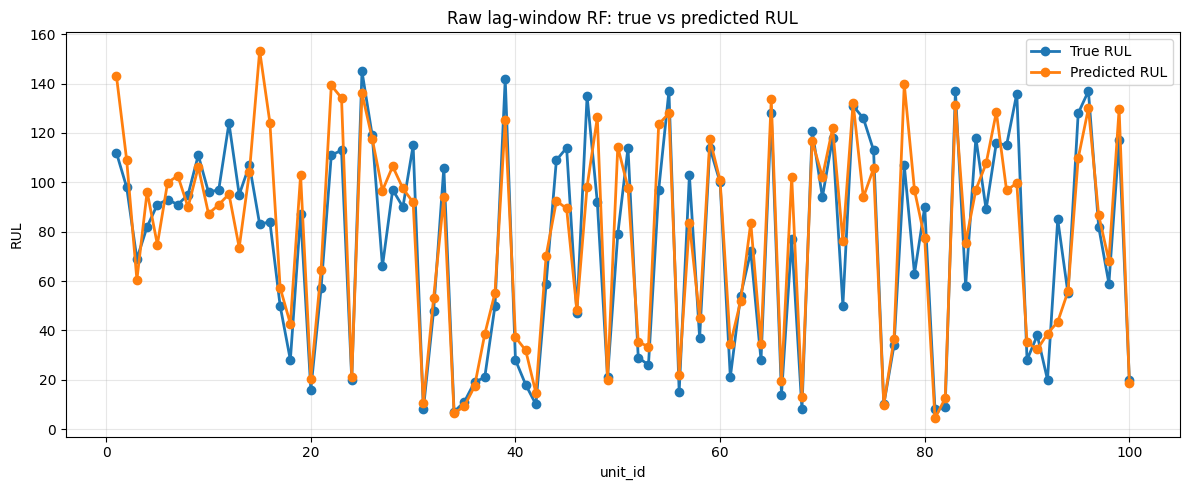

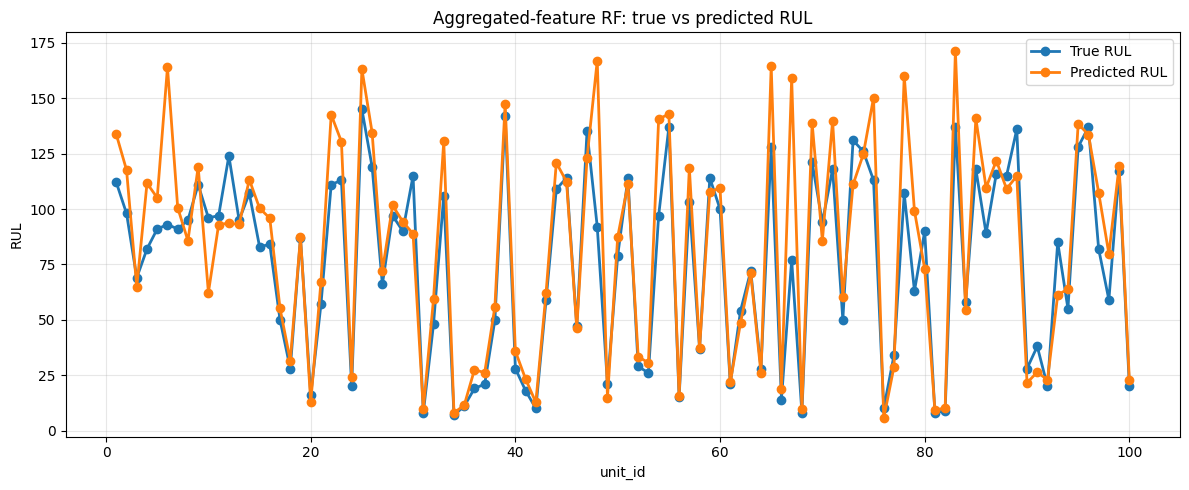

In [9]:
def plot_true_vs_pred(error_df, title):
    plt.figure(figsize=(12, 5))
    plt.plot(
        error_df["unit_id"],
        error_df["true_rul"],
        marker="o",
        linewidth=2,
        label="True RUL",
    )
    plt.plot(
        error_df["unit_id"],
        error_df["pred_rul"],
        marker="o",
        linewidth=2,
        label="Predicted RUL",
    )
    plt.title(title)
    plt.xlabel("unit_id")
    plt.ylabel("RUL")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_true_vs_pred(raw_error_df, "Raw lag-window RF: true vs predicted RUL")
plot_true_vs_pred(agg_error_df, "Aggregated-feature RF: true vs predicted RUL")

По общей форме графика видно, что модель в целом улавливает порядок величины RUL, но на отдельных двигателях сильно ошибается. Поэтому одной средней метрики MAE недостаточно: нужно смотреть ошибки по отдельным unit_id.

## 4. Ошибка по каждому двигателю

Ошибка считается как predicted RUL минус true RUL. Если ошибка положительная, модель завысила остаточный ресурс. Для авиационного обслуживания это опаснее, чем занижение: при завышении модель считает, что двигатель может работать дольше, чем на самом деле.

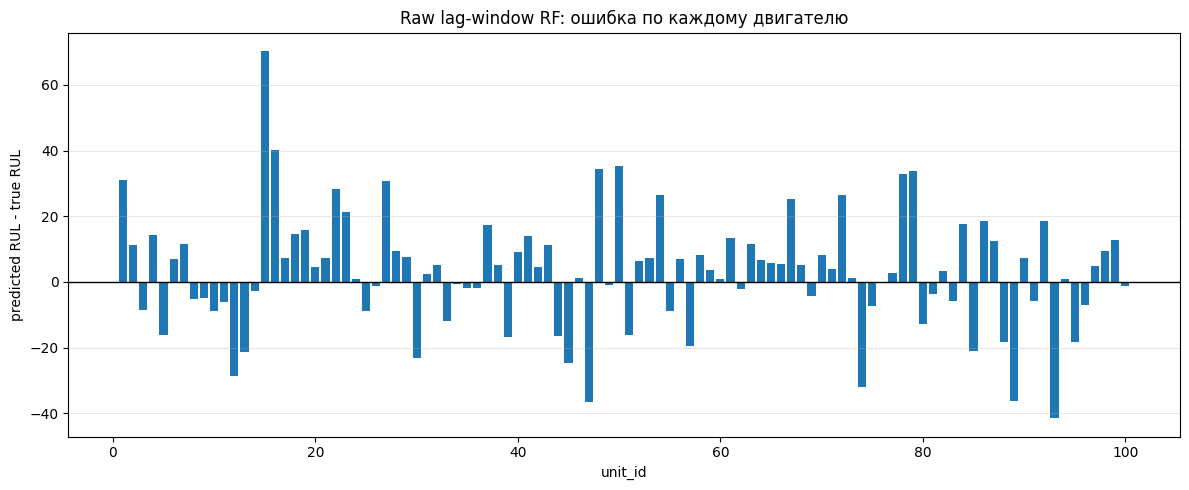

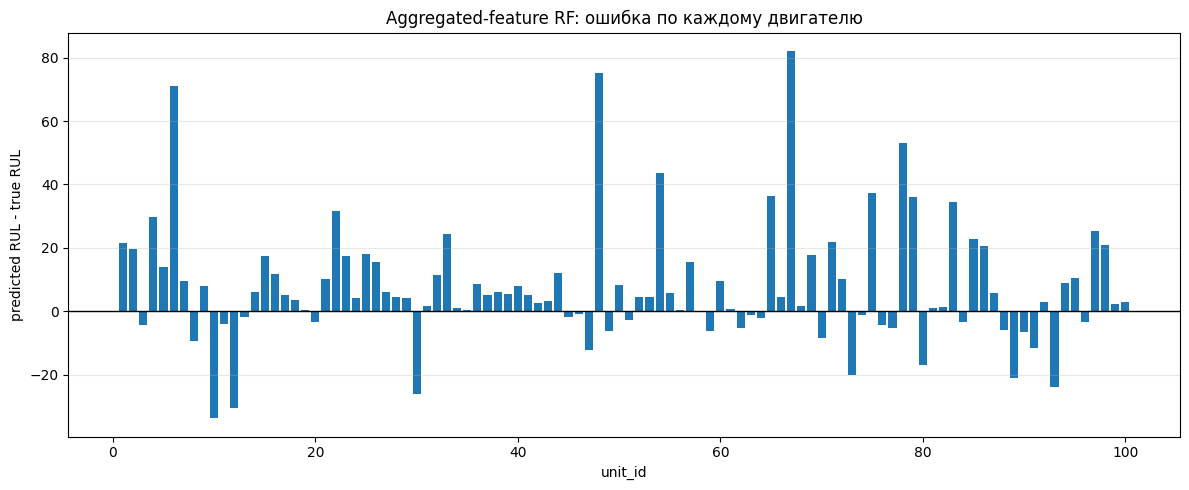

,model_name,unit_id,true_rul,pred_rul,error,abs_error,error_type
0,Raw lag-window RF,1,112,143.177993,31.177993,31.177993,overestimation
1,Raw lag-window RF,2,98,109.125343,11.125343,11.125343,overestimation
2,Raw lag-window RF,3,69,60.503441,-8.496559,8.496559,underestimation
3,Raw lag-window RF,4,82,96.199504,14.199504,14.199504,overestimation
4,Raw lag-window RF,5,91,74.778997,-16.221003,16.221003,underestimation


,model_name,unit_id,true_rul,pred_rul,error,abs_error,error_type
0,Aggregated-feature RF,1,112,133.651842,21.651842,21.651842,overestimation
1,Aggregated-feature RF,2,98,117.608104,19.608104,19.608104,overestimation
2,Aggregated-feature RF,3,69,64.807622,-4.192378,4.192378,underestimation
3,Aggregated-feature RF,4,82,111.627089,29.627089,29.627089,overestimation
4,Aggregated-feature RF,5,91,105.056927,14.056927,14.056927,overestimation


In [10]:
def plot_prediction_error(error_df, title):
    plt.figure(figsize=(12, 5))
    plt.bar(error_df["unit_id"], error_df["error"])
    plt.axhline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("unit_id")
    plt.ylabel("predicted RUL - true RUL")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_prediction_error(raw_error_df, "Raw lag-window RF: ошибка по каждому двигателю")
plot_prediction_error(
    agg_error_df, "Aggregated-feature RF: ошибка по каждому двигателю"
)
display(raw_error_df.head())
display(agg_error_df.head())

## 5. Почему overestimation важнее MAE

MAE симметрична: она одинаково штрафует ошибку +20 и ошибку -20. Но в задаче RUL эти ошибки имеют разный смысл.

Если модель занижает RUL, двигатель могут отправить на обслуживание раньше. Это плохо экономически, но безопаснее.

Если модель завышает RUL, двигатель могут оставить в работе слишком долго. Это уже safety-риск.

Поэтому кроме MAE, RMSE и R2 мы считаем:
- overestimation_count;
- overestimation_share;
- mean_overestimation;
- max_overestimation;
- near_failure_overestimation_share.

## 6. Сводка safety-метрик

In [11]:
raw_safety = safety_summary(raw_error_df)
agg_safety = safety_summary(agg_error_df)

safety_summary_df = pd.DataFrame(
    [
        {**raw_safety, "train_seconds": raw_train_seconds},
        {**agg_safety, "train_seconds": agg_train_seconds},
    ]
)
safety_summary_df[
    [
        "model_name",
        "MAE",
        "RMSE",
        "R2",
        "mean_error",
        "median_abs_error",
        "overestimation_count",
        "overestimation_share",
        "mean_overestimation",
        "max_overestimation",
        "near_failure_MAE",
        "near_failure_overestimation_share",
        "train_seconds",
    ]
]

,model_name,MAE,RMSE,R2,mean_error,median_abs_error,overestimation_count,overestimation_share,mean_overestimation,max_overestimation,near_failure_MAE,near_failure_overestimation_share,train_seconds
0,Raw lag-window RF,13.299888,17.901184,0.814432,3.106353,8.946425,60,0.6,13.671868,70.352008,6.312309,0.72,207.644770
1,Aggregated-feature RF,13.378653,20.502347,0.756585,7.716741,7.128084,70,0.7,15.068139,82.093908,3.499732,0.80,71.103179


In [12]:
raw_mae = raw_safety["MAE"]
agg_mae = agg_safety["MAE"]
raw_over = raw_safety["overestimation_share"]
agg_over = agg_safety["overestimation_share"]
speed_ratio = raw_train_seconds / agg_train_seconds if agg_train_seconds > 0 else np.nan
interpretation = (
    f"По фактическим числам raw-window модель имеет MAE {raw_mae:.3f}, а агрегатная модель имеет MAE {agg_mae:.3f}. "
    f"Время обучения raw-window модели: {raw_train_seconds:.1f} сек., агрегатной модели: {agg_train_seconds:.1f} сек.; "
    f"raw-window линия обучается примерно в {speed_ratio:.1f} раза дольше. "
    f"Доля завышений RUL у raw-window модели равна {raw_over:.1%}, у агрегатной модели — {agg_over:.1%}. "
    "Это показывает, что raw-window модель сильнее как исходный baseline по глобальным метрикам, но агрегатная модель может быть привлекательнее, если важны скорость итераций, интерпретируемость и safety-oriented анализ ошибок."
)
display(Markdown(interpretation))

По фактическим числам raw-window модель имеет MAE 13.300, а агрегатная модель имеет MAE 13.379. Время обучения raw-window модели: 207.6 сек., агрегатной модели: 71.1 сек.; raw-window линия обучается примерно в 2.9 раза дольше. Доля завышений RUL у raw-window модели равна 60.0%, у агрегатной модели — 70.0%. Это показывает, что raw-window модель сильнее как исходный baseline по глобальным метрикам, но агрегатная модель может быть привлекательнее, если важны скорость итераций, интерпретируемость и safety-oriented анализ ошибок.

## 7. Консервативная калибровка

Так как у моделей есть склонность завышать RUL, мы проверяем простую консервативную калибровку. Она не меняет саму модель, а применяется как постобработка предсказаний:

`calibrated_prediction = max(original_prediction - shift, 0)`

Идея: если модель систематически завышает остаточный ресурс, можно сдвинуть прогноз вниз на небольшое число циклов. Тогда прогноз становится осторожнее.

In [13]:
def apply_shift(error_df, shift):
    shifted_df = error_df.copy()
    shifted_df["pred_rul"] = np.maximum(shifted_df["pred_rul"] - shift, 0)
    shifted_df["error"] = shifted_df["pred_rul"] - shifted_df["true_rul"]
    shifted_df["abs_error"] = shifted_df["error"].abs()
    shifted_df["error_type"] = np.select(
        [shifted_df["error"] > 0, shifted_df["error"] < 0],
        ["overestimation", "underestimation"],
        default="exact",
    )
    return shifted_df


def evaluate_conservative_shifts(error_df, shifts):
    rows = []
    for shift in shifts:
        shifted_df = apply_shift(error_df, shift)
        summary = safety_summary(shifted_df)
        zone_summary = evaluate_by_rul_zones(shifted_df).set_index("zone")
        rows.append(
            {
                "model_name": error_df["model_name"].iloc[0],
                "shift": shift,
                "MAE": summary["MAE"],
                "RMSE": summary["RMSE"],
                "R2": summary["R2"],
                "mean_error": summary["mean_error"],
                "overestimation_count": summary["overestimation_count"],
                "overestimation_share": summary["overestimation_share"],
                "mean_overestimation": summary["mean_overestimation"],
                "max_overestimation": summary["max_overestimation"],
                "near_failure_MAE": zone_summary.loc["near_failure", "MAE"],
                "near_failure_overestimation_share": zone_summary.loc[
                    "near_failure", "overestimation_share"
                ],
                "warning_zone_MAE": zone_summary.loc["warning_zone", "MAE"],
                "warning_zone_overestimation_share": zone_summary.loc[
                    "warning_zone", "overestimation_share"
                ],
            }
        )
    return pd.DataFrame(rows)


raw_shift_results = evaluate_conservative_shifts(raw_error_df, shifts)
agg_shift_results = evaluate_conservative_shifts(agg_error_df, shifts)
display(raw_shift_results.sort_values("MAE").head(10))
display(agg_shift_results.sort_values("MAE").head(10))

,model_name,shift,MAE,RMSE,R2,mean_error,overestimation_count,overestimation_share,mean_overestimation,max_overestimation,near_failure_MAE,near_failure_overestimation_share,warning_zone_MAE,warning_zone_overestimation_share
45,Raw lag-window RF,4.5,12.879768,17.684171,0.818904,-1.392697,49,0.49,11.721501,65.852008,4.855064,0.56,8.912301,0.647059
43,Raw lag-window RF,4.3,12.880233,17.669967,0.819194,-1.193647,50,0.50,11.686586,66.052008,4.896922,0.60,8.971124,0.647059
41,Raw lag-window RF,4.1,12.880233,17.657585,0.819448,-0.993647,50,0.50,11.886586,66.252008,4.936922,0.60,9.029948,0.647059
44,Raw lag-window RF,4.4,12.880233,17.677004,0.819050,-1.293647,50,0.50,11.586586,65.952008,4.876922,0.60,8.941712,0.647059
42,Raw lag-window RF,4.2,12.880233,17.663494,0.819327,-1.093647,50,0.50,11.786586,66.152008,4.916922,0.60,9.000536,0.647059
40,Raw lag-window RF,4.0,12.880233,17.652240,0.819557,-0.893647,50,0.50,11.986586,66.352008,4.956922,0.60,9.059359,0.647059
46,Raw lag-window RF,4.6,12.880768,17.691873,0.818746,-1.491697,49,0.49,11.621501,65.752008,4.839064,0.56,8.882889,0.647059
39,Raw lag-window RF,3.9,12.881980,17.647460,0.819655,-0.793647,51,0.51,11.851307,66.452008,4.976922,0.60,9.088771,0.647059
47,Raw lag-window RF,4.7,12.883214,17.700130,0.818577,-1.590697,48,0.48,11.763038,65.652008,4.828846,0.52,8.853477,0.647059
38,Raw lag-window RF,3.8,12.883980,17.643245,0.819741,-0.693647,51,0.51,11.951307,66.552008,4.996922,0.60,9.118183,0.647059


,model_name,shift,MAE,RMSE,R2,mean_error,overestimation_count,overestimation_share,mean_overestimation,max_overestimation,near_failure_MAE,near_failure_overestimation_share,warning_zone_MAE,warning_zone_overestimation_share
46,Aggregated-feature RF,4.6,12.496160,19.248694,0.785443,3.116741,50,0.50,15.612901,77.493908,3.562174,0.20,8.088633,0.529412
45,Aggregated-feature RF,4.5,12.496729,19.265139,0.785076,3.216741,51,0.51,15.405362,77.593908,3.504450,0.24,8.094516,0.529412
44,Aggregated-feature RF,4.4,12.499343,19.282088,0.784698,3.316741,52,0.52,15.207772,77.693908,3.454905,0.28,8.100398,0.529412
47,Aggregated-feature RF,4.7,12.499970,19.232755,0.785798,3.016741,48,0.48,16.163241,77.393908,3.629667,0.16,8.082751,0.529412
43,Aggregated-feature RF,4.3,12.503634,19.299540,0.784308,3.416741,53,0.53,15.019222,77.793908,3.410905,0.28,8.106280,0.529412
48,Aggregated-feature RF,4.8,12.503970,19.217323,0.786142,2.916741,48,0.48,16.063241,77.293908,3.697667,0.16,8.076868,0.529412
49,Aggregated-feature RF,4.9,12.507970,19.202400,0.786474,2.816741,48,0.48,15.963241,77.193908,3.765667,0.16,8.070986,0.529412
42,Aggregated-feature RF,4.2,12.511147,19.317495,0.783906,3.516741,54,0.54,14.840636,77.893908,3.372954,0.32,8.112163,0.529412
50,Aggregated-feature RF,5.0,12.511970,19.187986,0.786794,2.716741,48,0.48,15.863241,77.093908,3.833667,0.16,8.065104,0.529412
51,Aggregated-feature RF,5.1,12.515970,19.174083,0.787103,2.616741,48,0.48,15.763241,76.993908,3.901667,0.16,8.059221,0.529412


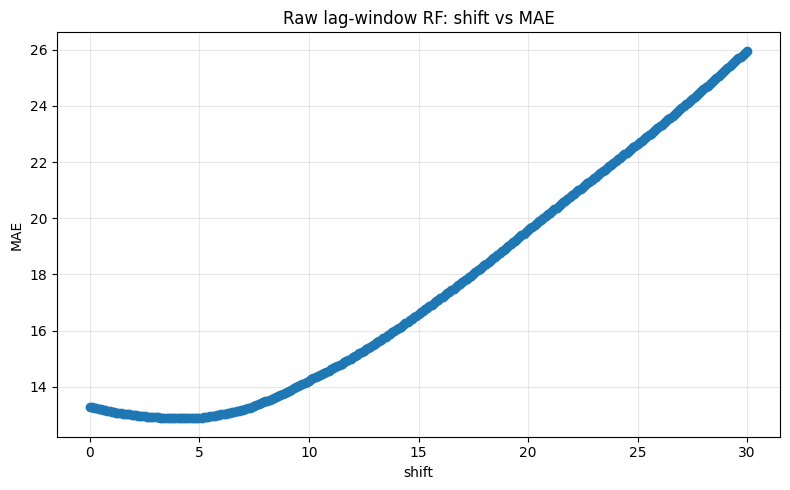

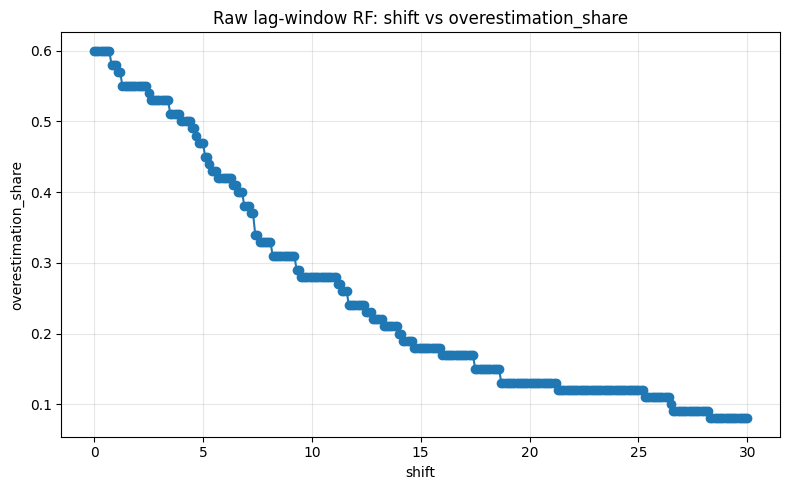

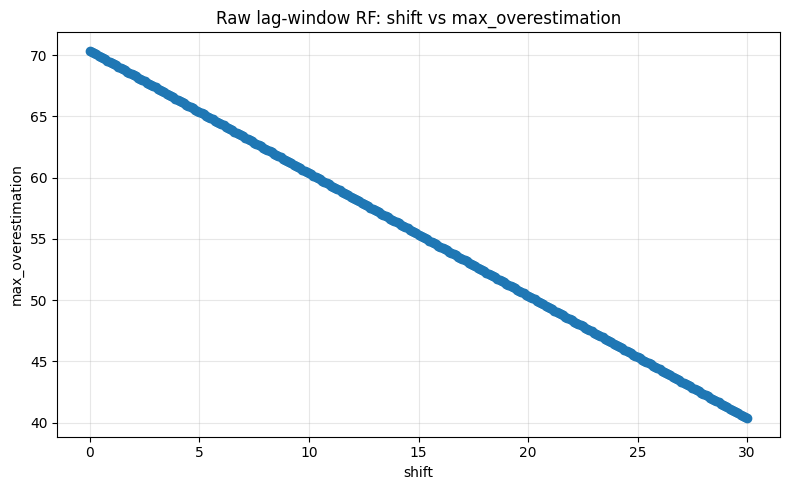

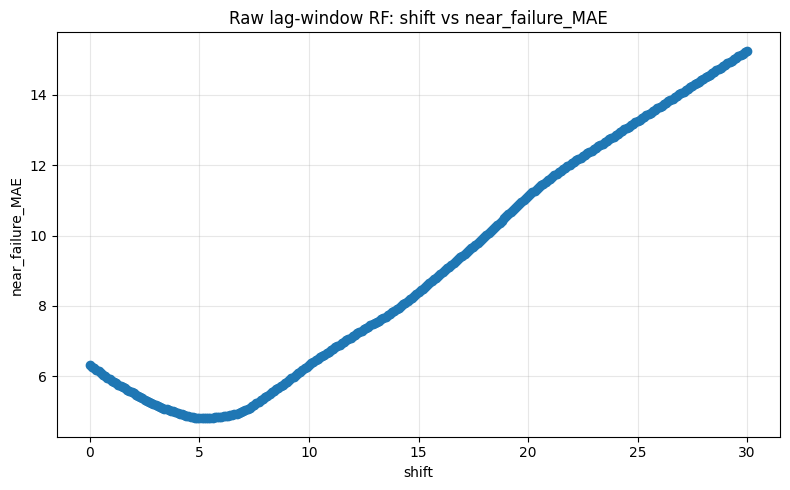

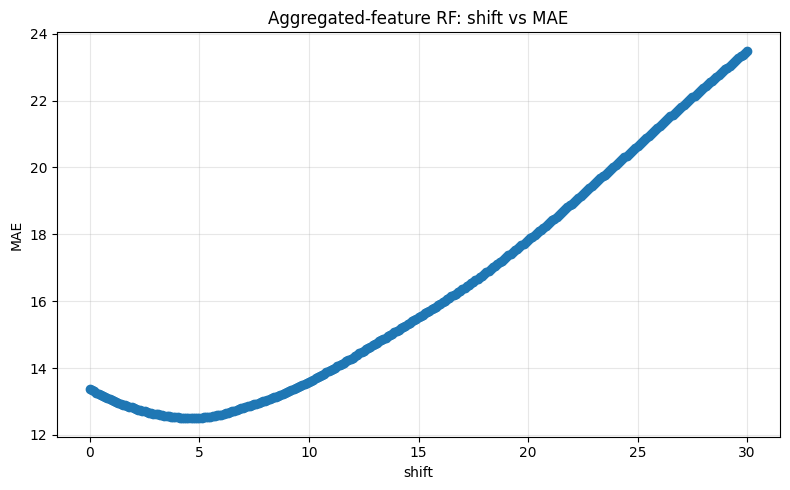

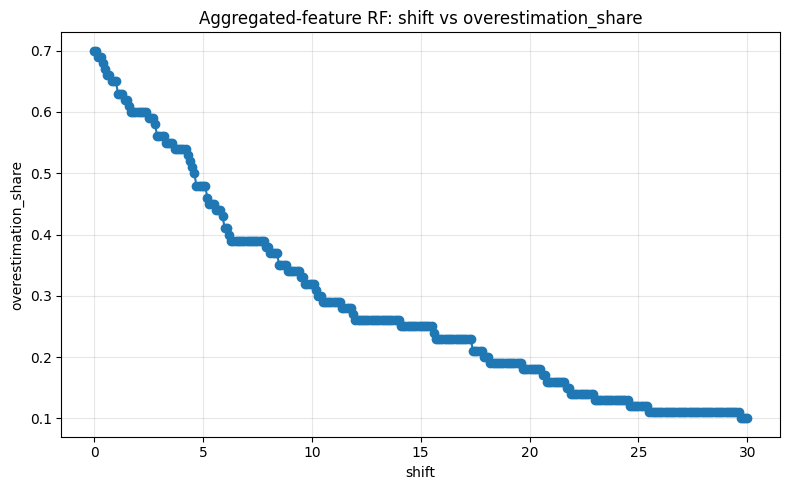

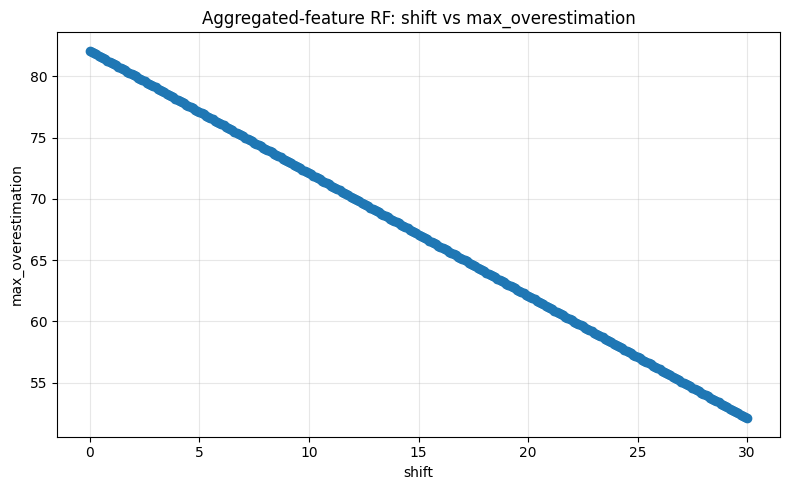

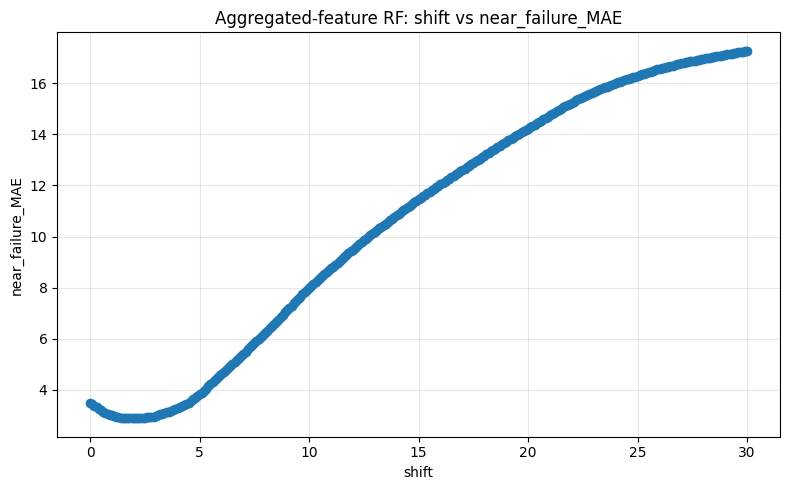

In [14]:
def plot_shift_metric(shift_results, metric, title):
    plt.figure(figsize=(8, 5))
    plt.plot(shift_results["shift"], shift_results[metric], marker="o")
    plt.title(title)
    plt.xlabel("shift")
    plt.ylabel(metric)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


for shift_results, model_name in [
    (raw_shift_results, "Raw lag-window RF"),
    (agg_shift_results, "Aggregated-feature RF"),
]:
    plot_shift_metric(shift_results, "MAE", f"{model_name}: shift vs MAE")
    plot_shift_metric(
        shift_results,
        "overestimation_share",
        f"{model_name}: shift vs overestimation_share",
    )
    plot_shift_metric(
        shift_results,
        "max_overestimation",
        f"{model_name}: shift vs max_overestimation",
    )
    plot_shift_metric(
        shift_results, "near_failure_MAE", f"{model_name}: shift vs near_failure_MAE"
    )

## 8. Быстрая проверка лучших shift

Ручной подбор shift убран, чтобы не пересчитывать лишнее. Здесь показываются лучшие уже посчитанные варианты из `raw_shift_results` и `agg_shift_results`.


In [18]:
best_shift_preview_df = pd.concat(
    [
        raw_shift_results.sort_values("MAE").head(5).assign(model_group="raw_window"),
        agg_shift_results.sort_values("MAE").head(5).assign(model_group="aggregated"),
    ],
    ignore_index=True,
)

best_shift_preview_df[
    [
        "model_group",
        "model_name",
        "shift",
        "MAE",
        "RMSE",
        "R2",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
    ]
]

,model_group,model_name,shift,MAE,RMSE,R2,overestimation_share,max_overestimation,near_failure_MAE
0,raw_window,Raw lag-window RF,4.5,12.879768,17.684171,0.818904,0.49,65.852008,4.855064
1,raw_window,Raw lag-window RF,4.3,12.880233,17.669967,0.819194,0.50,66.052008,4.896922
2,raw_window,Raw lag-window RF,4.1,12.880233,17.657585,0.819448,0.50,66.252008,4.936922
3,raw_window,Raw lag-window RF,4.4,12.880233,17.677004,0.819050,0.50,65.952008,4.876922
4,raw_window,Raw lag-window RF,4.2,12.880233,17.663494,0.819327,0.50,66.152008,4.916922
5,aggregated,Aggregated-feature RF,4.6,12.496160,19.248694,0.785443,0.50,77.493908,3.562174
6,aggregated,Aggregated-feature RF,4.5,12.496729,19.265139,0.785076,0.51,77.593908,3.504450
7,aggregated,Aggregated-feature RF,4.4,12.499343,19.282088,0.784698,0.52,77.693908,3.454905
8,aggregated,Aggregated-feature RF,4.7,12.499970,19.232755,0.785798,0.48,77.393908,3.629667
9,aggregated,Aggregated-feature RF,4.3,12.503634,19.299540,0.784308,0.53,77.793908,3.410905


## 9. Финальное сравнение после калибровки

Рекомендуемый shift выбирается как баланс между качеством и safety: MAE не должна ухудшиться больше чем на 10%, доля завышений должна снизиться, максимальное завышение должно снизиться. Если таких кандидатов нет, выбирается shift с минимальной MAE.

In [19]:
def select_recommended_shift(
    shift_results, baseline_mae, baseline_over_share, baseline_max_over
):
    candidates = shift_results[
        (shift_results["MAE"] <= baseline_mae * 1.10)
        & (shift_results["overestimation_share"] < baseline_over_share)
        & (shift_results["max_overestimation"] < baseline_max_over)
    ]
    if len(candidates):
        return candidates.sort_values(["MAE", "shift"]).iloc[0]
    return shift_results.sort_values(["MAE", "shift"]).iloc[0]


def final_comparison_row(error_df, shift_results, feature_type, train_seconds):
    original = safety_summary(error_df)
    recommended = select_recommended_shift(
        shift_results,
        original["MAE"],
        original["overestimation_share"],
        original["max_overestimation"],
    )
    return {
        "model_name": original["model_name"],
        "feature_type": feature_type,
        "train_seconds": train_seconds,
        "original_MAE": original["MAE"],
        "original_RMSE": original["RMSE"],
        "original_R2": original["R2"],
        "original_overestimation_share": original["overestimation_share"],
        "original_max_overestimation": original["max_overestimation"],
        "original_near_failure_MAE": original["near_failure_MAE"],
        "recommended_shift": recommended["shift"],
        "calibrated_MAE": recommended["MAE"],
        "calibrated_RMSE": recommended["RMSE"],
        "calibrated_R2": recommended["R2"],
        "calibrated_overestimation_share": recommended["overestimation_share"],
        "calibrated_max_overestimation": recommended["max_overestimation"],
        "calibrated_near_failure_MAE": recommended["near_failure_MAE"],
    }


final_comparison_df = pd.DataFrame(
    [
        final_comparison_row(
            raw_error_df, raw_shift_results, "raw_lag_window_100", raw_train_seconds
        ),
        final_comparison_row(
            agg_error_df, agg_shift_results, "aggregated_window_50", agg_train_seconds
        ),
    ]
)
final_comparison_df

,model_name,feature_type,train_seconds,original_MAE,original_RMSE,original_R2,original_overestimation_share,original_max_overestimation,original_near_failure_MAE,recommended_shift,calibrated_MAE,calibrated_RMSE,calibrated_R2,calibrated_overestimation_share,calibrated_max_overestimation,calibrated_near_failure_MAE
0,Raw lag-window RF,raw_lag_window_100,207.644770,13.299888,17.901184,0.814432,0.6,70.352008,6.312309,4.5,12.879768,17.684171,0.818904,0.49,65.852008,4.855064
1,Aggregated-feature RF,aggregated_window_50,71.103179,13.378653,20.502347,0.756585,0.7,82.093908,3.499732,4.6,12.496160,19.248694,0.785443,0.50,77.493908,3.562174


## 10. Итоговая рекомендация

1. Raw-window RandomForest остаётся самым сильным исходным baseline по чистым глобальным метрикам.
2. Однако он обучается намного дольше и использует большой сырой вектор признаков.
3. Aggregated-feature RandomForest быстрее и интерпретируемее.
4. После консервативной калибровки агрегатная модель может стать более практичным выбором, если у неё лучше calibrated MAE, ниже overestimation share или лучше поведение в near-failure зоне.
5. Для этого проекта финальную модель нельзя выбирать только по MAE.
6. Так как это задача RUL для авиационного двигателя, overestimation является safety-critical ошибкой.
7. Главный результат третьей недели — переход от оптимизации только средней ошибки к safety-oriented оценке.

Итоговый вывод: если оценивать только исходную MAE, модель на сыром окне остаётся лучшим baseline. Однако для практической RUL-задачи важна не только средняя ошибка, но и характер ошибок. Завышение остаточного ресурса опаснее занижения, потому что может привести к слишком позднему обслуживанию двигателя. После консервативной калибровки агрегатная модель становится более привлекательной практической кандидатурой: она быстрее обучается, использует более понятные признаки и может давать лучшее safety-oriented поведение.

## 11. Финальная таблица

Сохранение CSV убрано. Для финального просмотра достаточно перезапустить ячейку с `final_comparison_df` и эту ячейку.


In [20]:
final_comparison_df

,model_name,feature_type,train_seconds,original_MAE,original_RMSE,original_R2,original_overestimation_share,original_max_overestimation,original_near_failure_MAE,recommended_shift,calibrated_MAE,calibrated_RMSE,calibrated_R2,calibrated_overestimation_share,calibrated_max_overestimation,calibrated_near_failure_MAE
0,Raw lag-window RF,raw_lag_window_100,207.644770,13.299888,17.901184,0.814432,0.6,70.352008,6.312309,4.5,12.879768,17.684171,0.818904,0.49,65.852008,4.855064
1,Aggregated-feature RF,aggregated_window_50,71.103179,13.378653,20.502347,0.756585,0.7,82.093908,3.499732,4.6,12.496160,19.248694,0.785443,0.50,77.493908,3.562174
